<a href="https://colab.research.google.com/github/yadavprakash87/Titanic-Survival-Prediction/blob/main/Tytanic_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


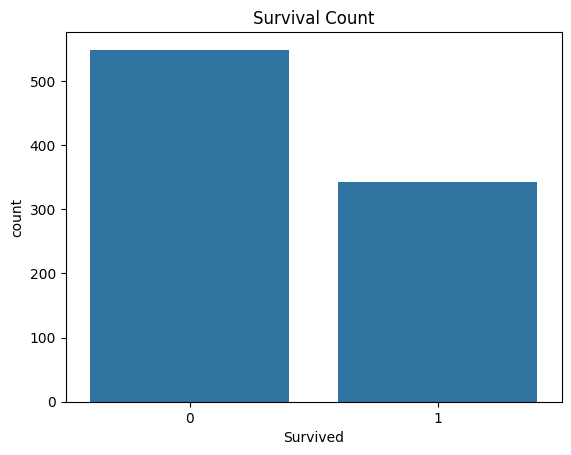

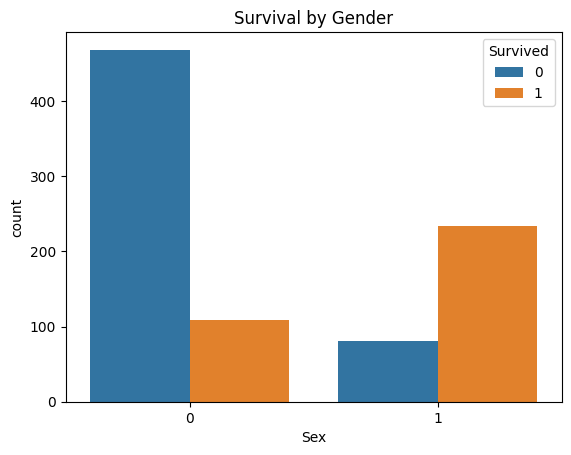

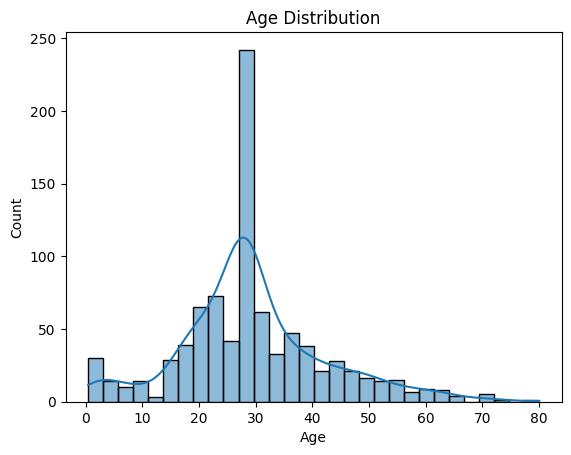

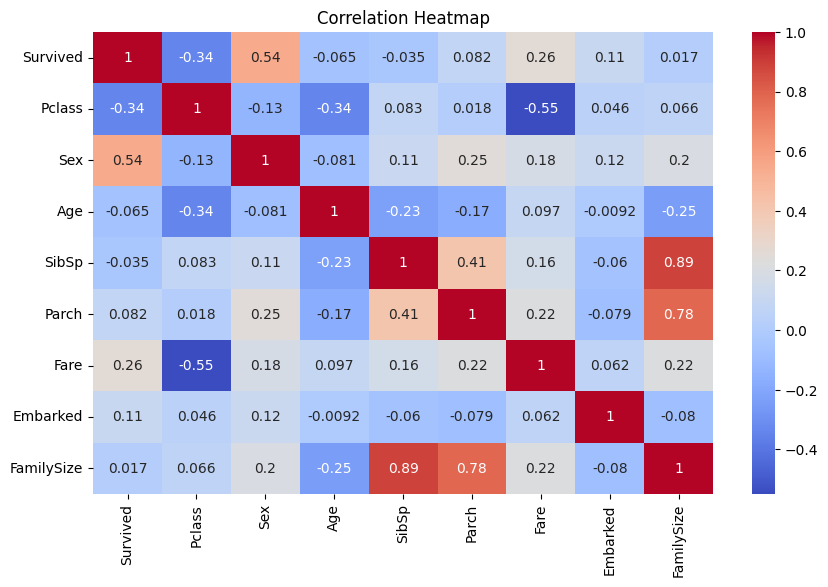

## Accuracy: 80.45%

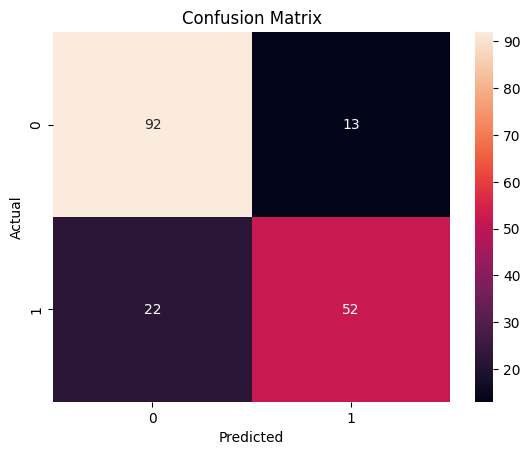

In [21]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown

# Step 2: Load Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Show first rows
df.head()

# Step 3: Data Cleaning
# Check missing values
print(df.isnull().sum())

# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column (too many missing values) and other non-numeric columns
df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'], inplace=True)

# Step 4: Feature Engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Convert categorical to numeric
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Step 5: Data Visualization

# Survival Count
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

# Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

# Age Distribution
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Step 6: Model Building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Features
X = df[['Age', 'Sex', 'Pclass', 'Fare', 'FamilySize']]
y = df['Survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Step 7: Prediction
y_pred = model.predict(X_test)

# Step 8: Evaluation
accuracy = accuracy_score(y_test, y_pred)
display(Markdown(f"## Accuracy: {accuracy:.2%}"))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()